# Error analysis 1: class support and domain shift

This notebook keeps three questions separate because they use different task settings.

**A. Class support:** BioDCASE → BioDCASE, `sp5` species classification.  
**B. Cross-corpus:** BioDCASE/HumbugDB → another corpus, `sp5` species classification.  
**C. Within-MIRU:** indoor ↔ outdoor, `sx9` species+sex classification.  
**D. Mixed MIRU training:** indoor+outdoor → indoor/outdoor, also `sx9`.

`sp5` and `sx9` are not combined into one performance comparison.


In [52]:
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.metrics import f1_score

ROOT = Path("/home/mosbnet/mosdet/mosbeatnet_main"); OUTPUT = ROOT/"output"; OUT_DIR = ROOT/"data"/"err_analytic"
OUT_DIR.mkdir(parents=True, exist_ok=True); TARGET_MODEL = "mosbeatnet_v2"
plt.rcParams.update({"figure.dpi":110, "axes.spines.top":False, "axes.spines.right":False})

def train_source(x):
    x = str(x).lower()
    if "exp1_indoor" in x: return "MIRU-indoor"
    if "exp2_outdoor" in x: return "MIRU-outdoor"
    if "exp3_humbug" in x: return "HumbugDB"
    if "exp4_biodcase" in x: return "BioDCASE"
    if "exp5_indoor_outdoor" in x: return "MIRU indoor+outdoor"
    if "exp6_all_sources" in x: return "All sources"
    return "Other"

def test_source(x):
    x = str(x).lower()
    if "biodcase" in x: return "BioDCASE"
    if "humbug" in x: return "HumbugDB"
    if "indoor" in x: return "MIRU-indoor"
    if "outdoor" in x: return "MIRU-outdoor"
    return "Other"

def task_of(exp): return "species_sex" if str(exp).endswith("_sx9") else "species"

def save(name):
    plt.savefig(OUT_DIR/f"{name}.png", dpi=200, bbox_inches="tight")


## 1. Load latest evaluated run

For every experiment × model × seed, use the latest run that actually contains
`all_environment_evaluation_summary.csv`. Weighted-sampling (`_ws`) experiments are excluded.


In [53]:
selected, frames = [], []
for exp in sorted(OUTPUT.glob("xdomain_exp*")):
    if "_ws" in exp.name or not exp.is_dir(): continue
    for model in exp.iterdir():
        if not model.is_dir(): continue
        for seed in model.glob("seed_*"):
            candidates = [(r,r/"evaluation"/"best_macro_f1"/"all_environment_evaluation_summary.csv") for r in seed.glob("run_*")]
            candidates = [(r,p) for r,p in candidates if p.exists()]
            if not candidates: continue
            run,p = sorted(candidates,key=lambda z:z[0].name)[-1]; df = pd.read_csv(p).rename(columns={"Eval Set":"Test Set","Evaluation Set":"Test Set"})
            df["Experiment"],df["Model"],df["Seed"] = exp.name,model.name,int(seed.name.replace("seed_",""))
            frames.append(df); selected.append({"Experiment":exp.name,"Model":model.name,"Seed":int(seed.name.replace("seed_","")),"Run":run})

if not frames: raise FileNotFoundError("No all_environment_evaluation_summary.csv found")

perf = pd.concat(frames,ignore_index=True,sort=False)
perf["Train"],perf["Task"] = perf["Experiment"].map(train_source),perf["Experiment"].map(task_of)
perf["Test"] = perf["Test Set"].map(test_source)
perf["Macro F1 %"] = pd.to_numeric(perf["Seg Macro F1"],errors="coerce")
if perf["Macro F1 %"].max() <= 1.5: perf["Macro F1 %"] *= 100

print("Summary rows:",len(perf),"| selected runs:",len(selected))
display(perf[["Experiment","Model","Seed","Task","Train","Test Set","Test","Macro F1 %"]].drop_duplicates().head(12))


Summary rows: 270 | selected runs: 30


,Experiment,Model,Seed,Task,Train,Test Set,Test,Macro F1 %
0,xdomain_exp1_indoor_sx9,mosqplus,42,species_sex,MIRU-indoor,all_domains,Other,40.63
1,xdomain_exp1_indoor_sx9,mosqplus,42,species_sex,MIRU-indoor,biodcase_forest,BioDCASE,34.22
2,xdomain_exp1_indoor_sx9,mosqplus,42,species_sex,MIRU-indoor,biodcase_urban,BioDCASE,33.65
3,xdomain_exp1_indoor_sx9,mosqplus,42,species_sex,MIRU-indoor,humbug_forest,HumbugDB,29.69
4,xdomain_exp1_indoor_sx9,mosqplus,42,species_sex,MIRU-indoor,humbug_urban,HumbugDB,30.41
5,xdomain_exp1_indoor_sx9,mosqplus,42,species_sex,MIRU-indoor,indoor_forest,MIRU-indoor,65.35
6,xdomain_exp1_indoor_sx9,mosqplus,42,species_sex,MIRU-indoor,indoor_urban,MIRU-indoor,62.20
7,xdomain_exp1_indoor_sx9,mosqplus,42,species_sex,MIRU-indoor,noise_only,Other,NaN
8,xdomain_exp1_indoor_sx9,mosqplus,42,species_sex,MIRU-indoor,outdoor_gaussian,MIRU-outdoor,8.75
9,xdomain_exp1_indoor_sx9,cfresnet1d_small,42,species_sex,MIRU-indoor,all_domains,Other,42.57


## 2. Does low class support relate to low in-domain F1?

**Setting:** BioDCASE → BioDCASE  
**Task:** `sp5`, species classification  
**Test sets:** BioDCASE urban + forest, pooled  
**Question:** Do classes with fewer evaluated 0.5-s test segments also tend to obtain lower F1?

Support is counted from actual evaluation segments, not simulation-event rows.


In [54]:
bio_frames = []
for x in selected:
    if x["Experiment"] != "xdomain_exp4_biodcase_sp5": continue
    for test in ["biodcase_urban","biodcase_forest"]:
        p = x["Run"]/"evaluation"/"best_macro_f1"/test/"segment_predictions.csv"
        if p.exists():
            d = pd.read_csv(p,low_memory=False); d["Model"],d["Seed"],d["Test Set"] = x["Model"],x["Seed"],test; bio_frames.append(d)

if not bio_frames: raise FileNotFoundError("No BioDCASE segment_predictions.csv found")

bio = pd.concat(bio_frames,ignore_index=True)
support = (bio[["Test Set","file_name","segment_index","true_label"]].drop_duplicates()
           .groupby("true_label").size().rename("Support").reset_index().rename(columns={"true_label":"Class"}))

rows = []
for (model,seed),g in bio.groupby(["Model","Seed"]):
    for cls in sorted(g["true_label"].astype(str).unique()):
        y = g["true_label"].astype(str).eq(cls); p = g["predicted_label"].astype(str).eq(cls)
        rows.append([model,seed,cls,f1_score(y,p,zero_division=0)])

class_f1 = pd.DataFrame(rows,columns=["Model","Seed","Class","F1"])
class_result = class_f1.groupby(["Model","Class"],as_index=False).agg(F1=("F1","mean")).merge(support,on="Class")
display(class_result.sort_values(["Support","Model"]).round(3))
class_result.to_csv(OUT_DIR/"class_support_f1_biodcase.csv",index=False)


,Model,Class,F1,Support
2,cfresnet1d_small,An.Dirus,0.001,210
7,mosbeatnet_v2,An.Dirus,0.000,210
12,mosqplus,An.Dirus,0.000,210
17,mtrcnn,An.Dirus,0.005,210
22,sednet,An.Dirus,0.002,210
1,cfresnet1d_small,Ae.Albopictus,0.645,10023
6,mosbeatnet_v2,Ae.Albopictus,0.639,10023
11,mosqplus,Ae.Albopictus,0.631,10023
16,mtrcnn,Ae.Albopictus,0.653,10023
21,sednet,Ae.Albopictus,0.631,10023


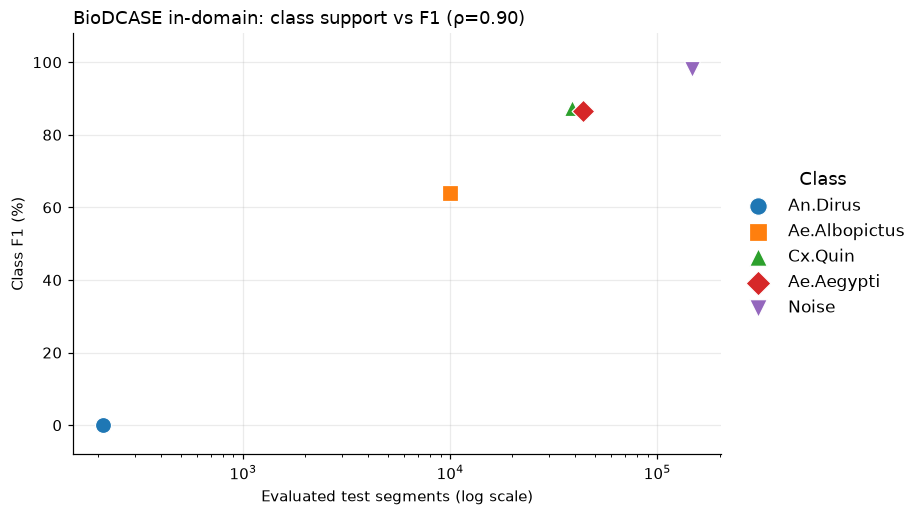

Spearman rho = 0.900 (descriptive only; n=5 classes)


In [70]:
x = class_result[class_result["Model"]==TARGET_MODEL].sort_values("Support")
rho = x["Support"].corr(x["F1"], method="spearman") if len(x)>1 else np.nan

colors  = plt.cm.tab10.colors
markers = ["o", "s", "^", "D", "v"]

fig, ax = plt.subplots(figsize=(8.5, 4.8))
for i, (_, r) in enumerate(x.iterrows()):
    ax.scatter(r["Support"], r["F1"]*100, s=110,
               color=colors[i % 10], marker=markers[i % len(markers)],
               edgecolor="white", linewidth=0.8, zorder=3, label=r["Class"])

ax.set_xscale("log")
ax.set_ylim(-8, 108)
ax.set_xlabel("Evaluated test segments (log scale)")
ax.set_ylabel("Class F1 (%)")
ax.set_title(f"BioDCASE in-domain: class support vs F1 (ρ={rho:.2f})", loc="left")
ax.grid(alpha=.25)

ax.legend(title="Class", frameon=False, loc="center left",
          bbox_to_anchor=(1.02, 0.5), fontsize=11, title_fontsize=12,
          markerscale=1.1, borderaxespad=0)

plt.tight_layout()
# save("fig_support_vs_f1_biodcase")
plt.show()

print(f"Spearman rho = {rho:.3f} (descriptive only; n={len(x)} classes)")

**Takeaway to read from this figure:** a positive association means lower-support classes also tend to have lower F1.  
A weak association means support alone does not explain the class-level errors. With only four mosquito species, treat ρ as descriptive rather than an inferential test.


## 3. Cross-corpus degradation

**Task:** `sp5`, species classification  
**Training:** BioDCASE or HumbugDB  
**Cross-corpus tests:** the other corpus plus MIRU indoor/outdoor  
**Reference:** the same model's in-domain performance on its training corpus

The six cross-corpus directions are:

- BioDCASE → HumbugDB / MIRU-indoor / MIRU-outdoor
- HumbugDB → BioDCASE / MIRU-indoor / MIRU-outdoor

BioDCASE → BioDCASE and HumbugDB → HumbugDB are used only as in-domain references.


In [56]:
sp = perf[(perf["Task"]=="species") & perf["Train"].isin(["BioDCASE","HumbugDB"]) &
          perf["Test"].isin(["BioDCASE","HumbugDB","MIRU-indoor","MIRU-outdoor"])].copy()

seed_perf = sp.groupby(["Model","Seed","Train","Test"],as_index=False)["Macro F1 %"].mean()
base = seed_perf[seed_perf["Train"]==seed_perf["Test"]][["Model","Seed","Train","Macro F1 %"]].rename(columns={"Macro F1 %":"In-domain F1 %"})
cross = seed_perf[seed_perf["Train"]!=seed_perf["Test"]].merge(base,on=["Model","Seed","Train"],how="left")
cross["Drop pp"] = cross["In-domain F1 %"]-cross["Macro F1 %"]; cross["Setting"] = cross["Train"]+" → "+cross["Test"]

cross_summary = cross.groupby(["Model","Setting","Train","Test"],as_index=False).agg(
    Mean_F1=("Macro F1 %","mean"),
    In_domain_F1=("In-domain F1 %","mean"),Mean_Drop_pp=("Drop pp","mean"))

display(cross_summary.round(2))
# cross_summary.to_csv(OUT_DIR/"cross_corpus_performance.csv",index=False)


,Model,Setting,Train,Test,Mean_F1,In_domain_F1,Mean_Drop_pp
0,cfresnet1d_small,BioDCASE → HumbugDB,BioDCASE,HumbugDB,52.39,67.36,14.97
1,cfresnet1d_small,BioDCASE → MIRU-indoor,BioDCASE,MIRU-indoor,38.78,67.36,28.58
2,cfresnet1d_small,BioDCASE → MIRU-outdoor,BioDCASE,MIRU-outdoor,9.33,67.36,58.03
3,cfresnet1d_small,HumbugDB → BioDCASE,HumbugDB,BioDCASE,35.67,85.04,49.37
4,cfresnet1d_small,HumbugDB → MIRU-indoor,HumbugDB,MIRU-indoor,34.46,85.04,50.59
5,cfresnet1d_small,HumbugDB → MIRU-outdoor,HumbugDB,MIRU-outdoor,25.52,85.04,59.53
6,mosbeatnet_v2,BioDCASE → HumbugDB,BioDCASE,HumbugDB,32.74,67.22,34.48
7,mosbeatnet_v2,BioDCASE → MIRU-indoor,BioDCASE,MIRU-indoor,35.29,67.22,31.93
8,mosbeatnet_v2,BioDCASE → MIRU-outdoor,BioDCASE,MIRU-outdoor,20.83,67.22,46.39
9,mosbeatnet_v2,HumbugDB → BioDCASE,HumbugDB,BioDCASE,36.20,87.89,51.68


### 3.1 Train-corpus × test-corpus map

**Question:** where does each species model generalize well or poorly?  
Diagonal cells are in-domain references; off-diagonal cells are domain-shift tests.


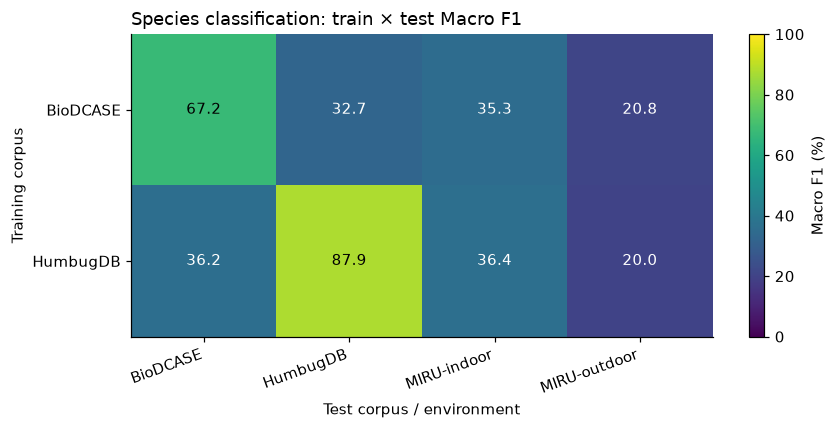

In [57]:
x = seed_perf[seed_perf["Model"]==TARGET_MODEL]
m = x.groupby(["Train","Test"])["Macro F1 %"].mean().unstack()
row_order = [v for v in ["BioDCASE","HumbugDB"] if v in m.index]
col_order = [v for v in ["BioDCASE","HumbugDB","MIRU-indoor","MIRU-outdoor"] if v in m.columns]
m = m.reindex(index=row_order,columns=col_order)

fig,ax = plt.subplots(figsize=(8,4))
im = ax.imshow(m.values,cmap="viridis",vmin=0,vmax=100,aspect="auto")
ax.set_xticks(range(len(m.columns)),m.columns,rotation=20,ha="right"); ax.set_yticks(range(len(m.index)),m.index)
for i in range(m.shape[0]):
    for j in range(m.shape[1]):
        v = m.iloc[i,j]
        if pd.notna(v): ax.text(j,i,f"{v:.1f}",ha="center",va="center",color="white" if v<50 else "black")
ax.set_xlabel("Test corpus / environment"); ax.set_ylabel("Training corpus")
ax.set_title("Species classification: train × test Macro F1",loc="left")
fig.colorbar(im,ax=ax,label="Macro F1 (%)"); plt.tight_layout(); 
# save("fig_cross_corpus_heatmap"); 
plt.show()


### 3.2 How much F1 is lost relative to in-domain?

**Question:** what is the magnitude of degradation for each cross-corpus direction?  
The line starts at cross-corpus performance and ends at the matched in-domain reference.


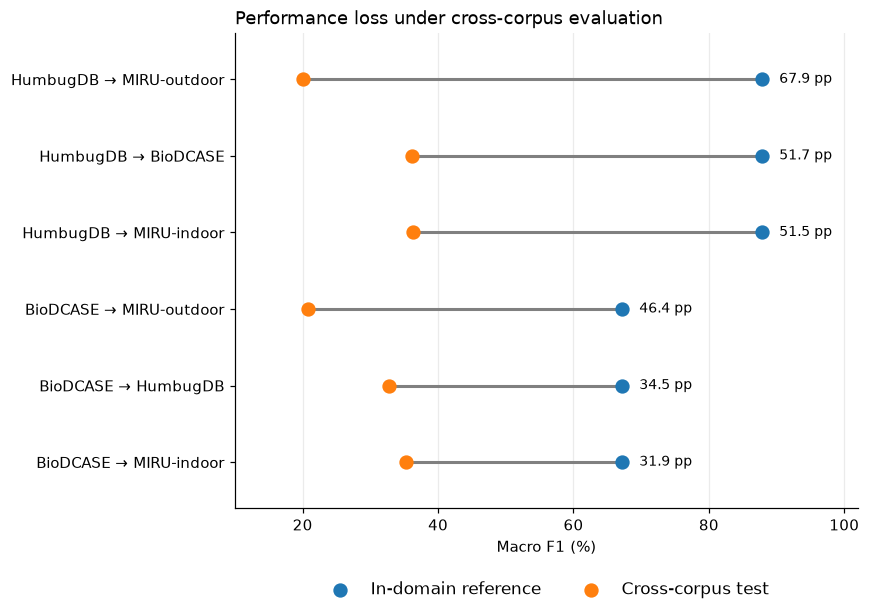

In [ ]:
d = cross[cross["Model"]==TARGET_MODEL].groupby("Setting")[["In-domain F1 %","Macro F1 %","Drop pp"]].mean().dropna().sort_values("Drop pp")
fig,ax = plt.subplots(figsize=(8,0.62*len(d)+2)); y = np.arange(len(d))
ax.hlines(y,d["Macro F1 %"],d["In-domain F1 %"],color="grey",lw=2)
ax.scatter(d["In-domain F1 %"],y,s=70,label="In-domain reference",zorder=3)
ax.scatter(d["Macro F1 %"],y,s=70,label="Cross-corpus test",zorder=3)
for i,r in enumerate(d.itertuples()):
    ax.text(max(r[1],r[2])+2.5, i, f"{r[3]:.1f} pp", va="center", ha="left", fontsize=9)

ax.set_yticks(y, d.index); ax.set_xlabel("Macro F1 (%)"); ax.set_ylabel("")
ax.set_title("Performance loss under cross-corpus evaluation", loc="left")
ax.set_xlim(10, 102)                       
ax.set_ylim(-0.6, len(d)-0.4)              
ax.legend(frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.14),ncol=2, fontsize=11, borderaxespad=0)
ax.grid(axis="x", alpha=.25)
plt.tight_layout(); plt.savefig("fig_cross_corpus_dumbbell.png", dpi=300, bbox_inches="tight"); plt.show()


### 3.3 Seed-level degradation

Each dot is one training seed. This shows whether a mean drop is consistent across repeats rather than being driven by one run.


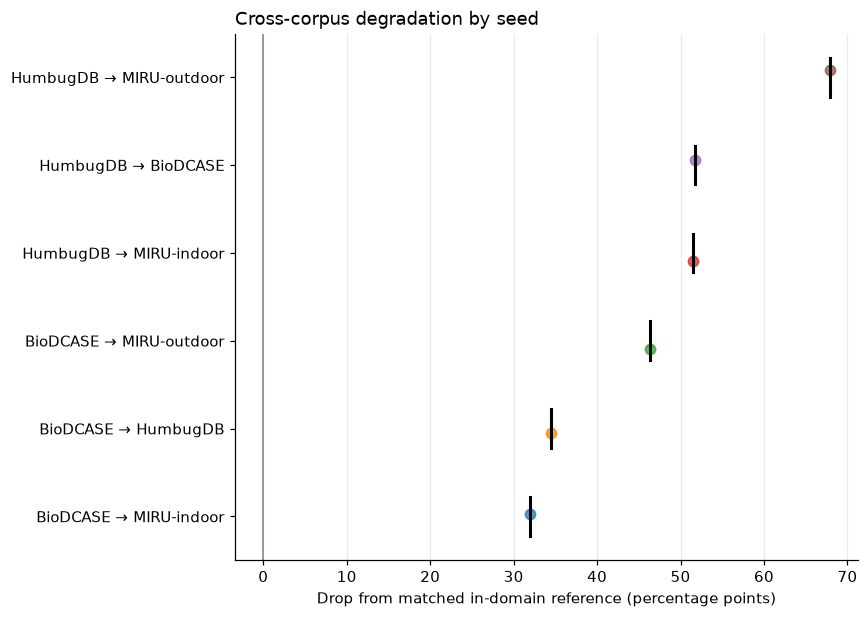

In [59]:
c = cross[cross["Model"]==TARGET_MODEL].copy()
order = c.groupby("Setting")["Drop pp"].mean().sort_values().index
fig,ax = plt.subplots(figsize=(8,0.62*len(order)+2)); rng = np.random.default_rng(0)
for i,s in enumerate(order):
    v = c.loc[c["Setting"]==s,"Drop pp"].dropna()
    ax.scatter(v,i+rng.uniform(-.10,.10,len(v)),s=45,alpha=.75)
    if len(v): ax.plot([v.mean()]*2,[i-.22,i+.22],color="black",lw=2)
ax.set_yticks(range(len(order)),order); ax.axvline(0,color="grey",lw=1)
ax.set_xlabel("Drop from matched in-domain reference (percentage points)"); ax.set_ylabel("")
ax.set_title("Cross-corpus degradation by seed",loc="left")
ax.grid(axis="x",alpha=.25); plt.tight_layout(); save("fig_cross_corpus_seed_drop"); plt.show()


### 3.4 Compact takeaway table

Use this table to answer three descriptive questions:

1. Are the cross-corpus drops positive?
2. Which target setting has the largest mean drop?
3. Is the shift asymmetric, for example BioDCASE → HumbugDB versus HumbugDB → BioDCASE?


In [60]:
take_cross = cross_summary[cross_summary["Model"]==TARGET_MODEL][["Setting","Mean_F1","In_domain_F1","Mean_Drop_pp"]].sort_values("Mean_Drop_pp",ascending=False)
display(take_cross.round(2))
# take_cross.to_csv(OUT_DIR/"takeaway_cross_corpus_mosbeatnet.csv",index=False)


,Setting,Mean_F1,In_domain_F1,Mean_Drop_pp
11,HumbugDB → MIRU-outdoor,20.02,87.89,67.87
9,HumbugDB → BioDCASE,36.20,87.89,51.68
10,HumbugDB → MIRU-indoor,36.35,87.89,51.54
8,BioDCASE → MIRU-outdoor,20.83,67.22,46.39
6,BioDCASE → HumbugDB,32.74,67.22,34.48
7,BioDCASE → MIRU-indoor,35.29,67.22,31.93


## 4. Within-MIRU environment transfer

**Task:** `sx9`, species+sex classification  
**Training:** MIRU-indoor or MIRU-outdoor  
**Testing:** same or opposite MIRU environment  
**Reference:** same-environment performance

This is **not cross-corpus**. The corpus remains MIRU; only the recording environment changes.


In [61]:
sx = perf[(perf["Task"]=="species_sex") & perf["Train"].isin(["MIRU-indoor","MIRU-outdoor"]) &
          perf["Test"].isin(["MIRU-indoor","MIRU-outdoor"])].copy()

sx_seed = sx.groupby(["Model","Seed","Train","Test"],as_index=False)["Macro F1 %"].mean()
sx_base = sx_seed[sx_seed["Train"]==sx_seed["Test"]][["Model","Seed","Train","Macro F1 %"]].rename(columns={"Macro F1 %":"In-domain F1 %"})
transfer = sx_seed[sx_seed["Train"]!=sx_seed["Test"]].merge(sx_base,on=["Model","Seed","Train"],how="left")
transfer["Drop pp"] = transfer["In-domain F1 %"]-transfer["Macro F1 %"]; transfer["Setting"] = transfer["Train"]+" → "+transfer["Test"]

transfer_summary = transfer.groupby(["Model","Setting","Train","Test"],as_index=False).agg(
    Mean_F1=("Macro F1 %","mean"),
    In_domain_F1=("In-domain F1 %","mean"),Mean_Drop_pp=("Drop pp","mean"))

display(transfer_summary.round(2))
# transfer_summary.to_csv(OUT_DIR/"within_miru_transfer.csv",index=False)


,Model,Setting,Train,Test,Mean_F1,In_domain_F1,Mean_Drop_pp
0,cfresnet1d_small,MIRU-indoor → MIRU-outdoor,MIRU-indoor,MIRU-outdoor,10.58,58.76,48.18
1,cfresnet1d_small,MIRU-outdoor → MIRU-indoor,MIRU-outdoor,MIRU-indoor,8.51,73.43,64.92
2,mosbeatnet_v2,MIRU-indoor → MIRU-outdoor,MIRU-indoor,MIRU-outdoor,9.71,74.44,64.72
3,mosbeatnet_v2,MIRU-outdoor → MIRU-indoor,MIRU-outdoor,MIRU-indoor,6.14,74.30,68.16
4,mosqplus,MIRU-indoor → MIRU-outdoor,MIRU-indoor,MIRU-outdoor,8.75,63.78,55.02
5,mosqplus,MIRU-outdoor → MIRU-indoor,MIRU-outdoor,MIRU-indoor,6.17,68.69,62.52
6,mtrcnn,MIRU-indoor → MIRU-outdoor,MIRU-indoor,MIRU-outdoor,9.73,68.92,59.19
7,mtrcnn,MIRU-outdoor → MIRU-indoor,MIRU-outdoor,MIRU-indoor,8.44,69.25,60.81
8,sednet,MIRU-indoor → MIRU-outdoor,MIRU-indoor,MIRU-outdoor,10.27,66.19,55.92
9,sednet,MIRU-outdoor → MIRU-indoor,MIRU-outdoor,MIRU-indoor,7.99,67.60,59.61


### 4.1 Indoor ↔ outdoor transfer loss

This directly compares each transfer result with its own same-environment baseline.


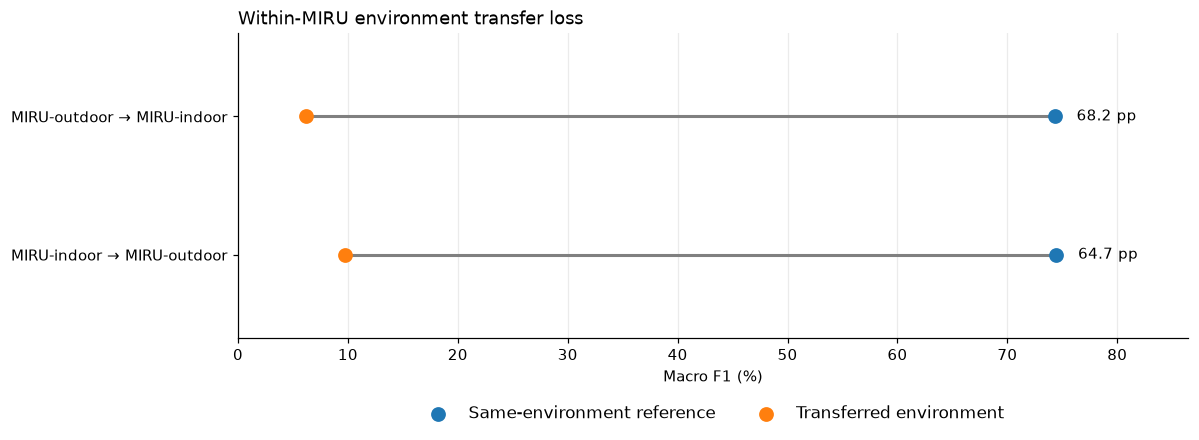

,Setting,Mean_F1,In_domain_F1,Mean_Drop_pp
2,MIRU-indoor → MIRU-outdoor,9.71,74.44,64.72
3,MIRU-outdoor → MIRU-indoor,6.14,74.30,68.16


In [78]:
d = transfer[transfer["Model"]==TARGET_MODEL].groupby("Setting")[["In-domain F1 %","Macro F1 %","Drop pp"]].mean().dropna().sort_values("Drop pp")
fig,ax = plt.subplots(figsize=(11,4.2)); y = np.arange(len(d))

ax.hlines(y,d["Macro F1 %"],d["In-domain F1 %"],color="grey",lw=2)
ax.scatter(d["In-domain F1 %"],y,s=75,label="Same-environment reference",zorder=3)
ax.scatter(d["Macro F1 %"],y,s=75,label="Transferred environment",zorder=3)

for i,r in enumerate(d.itertuples()):
    ax.text(max(r[1],r[2])+2,i,f"{r[3]:.1f} pp",va="center",ha="left",fontsize=10)

ax.set_yticks(y,d.index); ax.set_xlabel("Macro F1 (%)"); ax.set_ylabel("")
ax.set_title("Within-MIRU environment transfer loss",loc="left")
ax.set_xlim(0, max(d["In-domain F1 %"].max(), d["Macro F1 %"].max())+12)   # room for labels
ax.set_ylim(-0.6, len(d)-0.4)

ax.legend(frameon=False, loc="upper center", bbox_to_anchor=(0.5,-0.2),
          ncol=2, fontsize=11, borderaxespad=0)
ax.grid(axis="x",alpha=.25)

plt.tight_layout()
# plt.savefig("fig_within_miru_dumbbell.png", dpi=300, bbox_inches="tight")  # or keep save(...) if it uses bbox_inches="tight"
plt.show()

display(transfer_summary[transfer_summary["Model"]==TARGET_MODEL][["Setting","Mean_F1","In_domain_F1","Mean_Drop_pp"]].round(2))


### 4.2 Seed-level transfer loss

Use this only to judge consistency across seeds. It does not test statistical significance by itself.


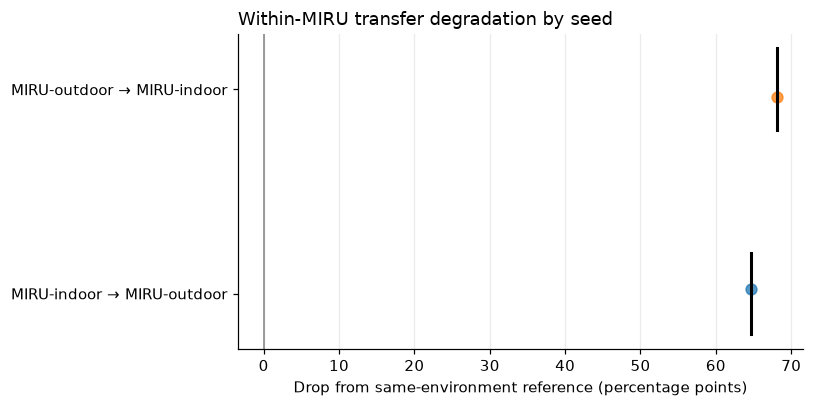

In [63]:
c = transfer[transfer["Model"]==TARGET_MODEL]
order = c.groupby("Setting")["Drop pp"].mean().sort_values().index
fig,ax = plt.subplots(figsize=(7.5,3.8)); rng = np.random.default_rng(0)
for i,s in enumerate(order):
    v = c.loc[c["Setting"]==s,"Drop pp"].dropna()
    ax.scatter(v,i+rng.uniform(-.08,.08,len(v)),s=50,alpha=.75)
    if len(v): ax.plot([v.mean()]*2,[i-.20,i+.20],color="black",lw=2)
ax.set_yticks(range(len(order)),order); ax.axvline(0,color="grey",lw=1)
ax.set_xlabel("Drop from same-environment reference (percentage points)"); ax.set_ylabel("")
ax.set_title("Within-MIRU transfer degradation by seed",loc="left")
ax.grid(axis="x",alpha=.25); plt.tight_layout(); save("fig_within_miru_seed_drop"); plt.show()


## 5. Does mixed indoor+outdoor training improve MIRU robustness?

**Task:** `sx9`, species+sex classification  
**Mixed model:** `exp5`, trained on MIRU indoor + outdoor  
**Comparison:** for each test environment, compare:

- same-environment single-source training,
- opposite-environment transfer,
- mixed indoor+outdoor training.

This section stays within the same `sx9` task, so the absolute F1 values are directly comparable.


In [64]:
mix = perf[(perf["Task"]=="species_sex") & perf["Train"].isin(["MIRU-indoor","MIRU-outdoor","MIRU indoor+outdoor"]) &
           perf["Test"].isin(["MIRU-indoor","MIRU-outdoor"])].copy()

mix_seed = mix.groupby(["Model","Seed","Train","Test"],as_index=False)["Macro F1 %"].mean()
mix_summary = mix_seed.groupby(["Model","Train","Test"],as_index=False).agg(Mean_F1=("Macro F1 %","mean"))
display(mix_summary[mix_summary["Model"]==TARGET_MODEL].round(2))
# mix_summary.to_csv(OUT_DIR/"miru_mixed_training.csv",index=False)


,Model,Train,Test,Mean_F1
6,mosbeatnet_v2,MIRU indoor+outdoor,MIRU-indoor,73.86
7,mosbeatnet_v2,MIRU indoor+outdoor,MIRU-outdoor,69.64
8,mosbeatnet_v2,MIRU-indoor,MIRU-indoor,74.44
9,mosbeatnet_v2,MIRU-indoor,MIRU-outdoor,9.71
10,mosbeatnet_v2,MIRU-outdoor,MIRU-indoor,6.14
11,mosbeatnet_v2,MIRU-outdoor,MIRU-outdoor,74.30


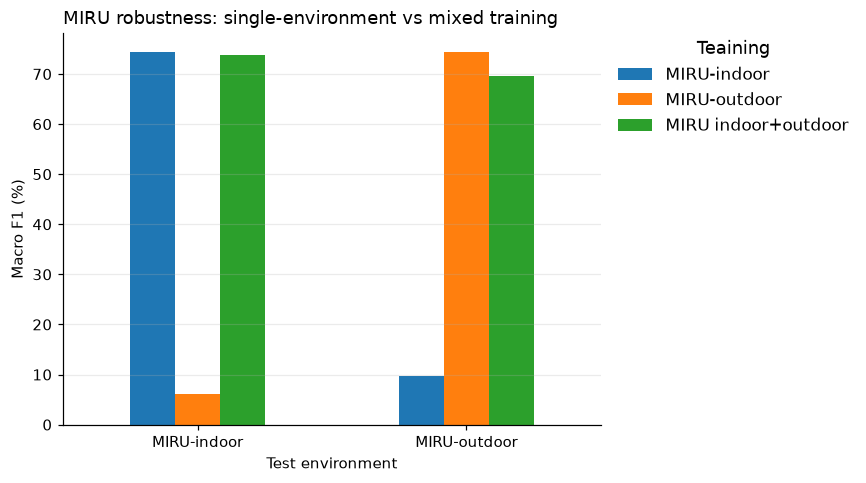

In [65]:
x = mix_summary[mix_summary["Model"]==TARGET_MODEL].copy()
train_order = ["MIRU-indoor","MIRU-outdoor","MIRU indoor+outdoor"]
test_order = ["MIRU-indoor","MIRU-outdoor"]
p = x.pivot(index="Test",columns="Train",values="Mean_F1").reindex(test_order).reindex(columns=train_order)
# e = x.pivot(index="Test",columns="Train",values="SD_F1").reindex(test_order).reindex(columns=train_order)

ax = p.plot.bar(yerr=e,figsize=(8,4.5),capsize=2)
ax.set_ylabel("Macro F1 (%)"); ax.set_xlabel("Test environment")
ax.set_title("MIRU robustness: single-environment vs mixed training",loc="left")
plt.xticks(rotation=0); ax.legend(title="Training",frameon=False); ax.grid(axis="y",alpha=.25)
ax.legend(title="Teaining",frameon=False, loc="upper left",
          bbox_to_anchor=(1.02, 1), borderaxespad=0, fontsize=11, title_fontsize=12)
ax.grid(axis="y", alpha=.25)
plt.tight_layout(); 
# save("fig_miru_mixed_training"); 
plt.show()


In [66]:
rows = []
for test in ["MIRU-indoor","MIRU-outdoor"]:
    d = mix_seed[(mix_seed["Model"]==TARGET_MODEL) & (mix_seed["Test"]==test)]
    same_train = test
    opposite = "MIRU-outdoor" if test=="MIRU-indoor" else "MIRU-indoor"
    a = d[d["Train"]==same_train].set_index("Seed")["Macro F1 %"]
    b = d[d["Train"]==opposite].set_index("Seed")["Macro F1 %"]
    m = d[d["Train"]=="MIRU indoor+outdoor"].set_index("Seed")["Macro F1 %"]
    common = a.index.intersection(b.index).intersection(m.index)
    if len(common):
        rows.append({
            "Test":test,
            "Same-env F1":a.loc[common].mean(),
            "Transfer F1":b.loc[common].mean(),
            "Mixed F1":m.loc[common].mean(),
            "Mixed - transfer pp":(m.loc[common]-b.loc[common]).mean(),
            "Mixed - same-env pp":(m.loc[common]-a.loc[common]).mean()
        })

mixed_takeaway = pd.DataFrame(rows)
display(mixed_takeaway.round(2))
# mixed_takeaway.to_csv(OUT_DIR/"takeaway_miru_mixed_training.csv",index=False)


,Test,Same-env F1,Transfer F1,Mixed F1,Mixed - transfer pp,Mixed - same-env pp
0,MIRU-indoor,74.44,6.14,73.86,67.71,-0.58
1,MIRU-outdoor,74.30,9.71,69.64,59.93,-4.66


## 6. What to report from this notebook

Keep the conclusions separated by task:

**BioDCASE class support (`sp5`):** report whether lower segment support is associated with lower class F1.  
**Cross-corpus (`sp5`):** report the F1 drop from each matched in-domain reference, the most affected target setting, and any directional asymmetry.  
**Within-MIRU (`sx9`):** report indoor → outdoor and outdoor → indoor transfer loss separately.  
**Mixed MIRU training (`sx9`):** report whether mixed training recovers performance relative to the opposite-environment transfer model and how it compares with the same-environment model.

Do not compare absolute `sp5` and `sx9` F1 as if they were the same classification task.
